# Evo-Hex — Painel de Visualizações (DEBUG)

Notebook de debug com subset de PDBs. Aponta para `debug/analysis/`.

**Pre-requisito:** `python debug.py` (padrao: 100 PDBs).

In [131]:
# ── Setup ────────────────────────────────────────────────────────────────────
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch

ROOT     = Path('/Volumes/promethion/cath')
ANALYSIS = ROOT / 'debug' / 'analysis'

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

ANALYSIS.mkdir(parents=True, exist_ok=True)
print(f'[DEBUG] Saída em: {ANALYSIS}')

[DEBUG] Saída em: /Volumes/promethion/cath/debug/analysis


---
## Estilo Global
Ajuste aqui para propagar para todos os plots.

In [132]:
# ── Estilo Global ─────────────────────────────────────────────────────────────
DPI           = 300              # resolução ao salvar
FONT_FAMILY   = 'Helvetica'      # 'Helvetica', 'Arial', 'DejaVu Sans', ...
FONT_TITLE    = 14               # tamanho do título
FONT_AXIS     = 12               # eixos x/y
FONT_TICK     = 10               # ticks
FONT_ANNOT    = 9                # anotações de texto nos gráficos
GRID_ALPHA    = 0                # 0 = sem grid

# ── Paleta Nature Publishing Group (NPG / ggsci) ──────────────────────────────
NPG = [
    '#E64B35',  # vermelho        → H (Alpha helix)
    '#4DBBD5',  # azul claro      → G (3-10 helix)
    '#00A087',  # verde-petróleo  → I (Pi helix)
    '#3C5488',  # azul escuro     → barras / pontos primários
    '#F39B7F',  # salmão          → comparação / contraste
    '#8491B4',  # lavanda
    '#91D1C2',  # verde claro
    '#DC0000',  # vermelho escuro → linhas de referência
    '#7E6148',  # marrom
    '#B09C85',  # cáqui
]

# Aliases convenientes
COR_H   = NPG[0]   # Alpha helix
COR_G   = NPG[1]   # 3-10 helix
COR_I   = NPG[2]   # Pi helix
COR_A   = NPG[3]   # barras / pontos primários
COR_B   = NPG[4]   # comparação / contraste
COR_REF = NPG[7]   # linhas de referência (--)

import matplotlib.font_manager as fm
sns.set_style('ticks')
plt.rcParams.update({
    'font.family'        : FONT_FAMILY,
    'font.size'          : FONT_TICK,
    'axes.titlesize'     : FONT_TITLE,
    'axes.labelsize'     : FONT_AXIS,
    'xtick.labelsize'    : FONT_TICK,
    'ytick.labelsize'    : FONT_TICK,
    'axes.grid'          : False,
    'savefig.dpi'        : DPI,
    'savefig.bbox'       : 'tight',
    'legend.framealpha'  : 0.9,
    'legend.edgecolor'   : '0.8',
    'legend.fontsize'    : FONT_TICK,
    'legend.title_fontsize': FONT_TICK,
    'legend.loc'         : 'best',
    'legend.borderpad'   : 0.6,
})

# Verifica se Helvetica está disponível; fallback para sans-serif
available = {f.name for f in fm.fontManager.ttflist}
if FONT_FAMILY not in available:
    fallback = 'Arial' if 'Arial' in available else 'DejaVu Sans'
    print(f'[AVISO] Fonte "{FONT_FAMILY}" nao encontrada. Usando "{fallback}".')
    plt.rcParams['font.family'] = fallback
else:
    print(f'Fonte: {FONT_FAMILY}')
print(f'Paleta NPG ativa. DPI={DPI}. Grid: desativado.')

Fonte: Helvetica
Paleta NPG ativa. DPI=300. Grid: desativado.


---
## Carregar Dados (CSVs — etapas 3-5)

In [133]:
# ── Etapa 3 (opcional no debug) ───────────────────────────────────────────────
_freq_path = ANALYSIS / 'amino_acid_frequencies_per_structure.csv'
freq_df = pd.read_csv(_freq_path) if _freq_path.exists() else None
if freq_df is None:
    print('[AVISO] amino_acid_frequencies_per_structure.csv nao encontrado (etapa 3 nao rodou). Ignorando.')

# ── Etapa 4 ───────────────────────────────────────────────────────────────────
propensity_df    = pd.read_csv(ANALYSIS / 'helix_propensities.csv')
positions_df     = pd.read_csv(ANALYSIS / 'helix_positions.csv')

# ── Etapa 5 ───────────────────────────────────────────────────────────────────
composition_df   = pd.read_csv(ANALYSIS / 'helix_type_composition.csv')
top_residues_df  = pd.read_csv(ANALYSIS / 'helix_type_top_residues.csv')
stat_df          = pd.read_csv(ANALYSIS / 'helix_type_statistical_comparison.csv')

print('CSVs carregados.')

[AVISO] amino_acid_frequencies_per_structure.csv nao encontrado (etapa 3 nao rodou). Ignorando.
CSVs carregados.


---
## Carregar Dados Evolutivos (etapa 6)

`evo_data` é salvo em `analysis/evo_data.pkl` na primeira execução (~3-4h).  
Nas execuções seguintes o pickle é lido instantaneamente.

In [134]:
from cath_analysis.evolutionary_analysis import (
    compute_hydrophobic_moments,
    compute_aa_cooccurrence,
    compute_helix_length_composition,
    compute_shannon_entropy_heptad,
)

PKL = ANALYSIS / 'evo_data.pkl'

if PKL.exists():
    import pickle
    with open(PKL, 'rb') as f:
        evo_data = pickle.load(f)
    print(f'evo_data carregado do cache ({PKL.name})')
else:
    raise FileNotFoundError(
        f'evo_data.pkl nao encontrado em {ANALYSIS}. '
        'Execute: python debug.py'
    )

# Dados derivados
moments        = compute_hydrophobic_moments(evo_data['helix_sequences'])
cooc_df        = compute_aa_cooccurrence(evo_data['helix_sequences'])
length_comp_df = compute_helix_length_composition(evo_data['per_helix_data'])
entropy_df     = compute_shannon_entropy_heptad(evo_data['heptad_aa_distribution'])
codon_df       = pd.read_csv(ANALYSIS / 'codon_degeneracy.csv')
proteome_df    = pd.read_csv(ANALYSIS / 'proteome_comparison.csv')

print('Dados evolutivos prontos.')

evo_data carregado do cache (evo_data.pkl)
Dados evolutivos prontos.


---
## Plot 1 — Propensão para Hélice: Observada vs Chou-Fasman

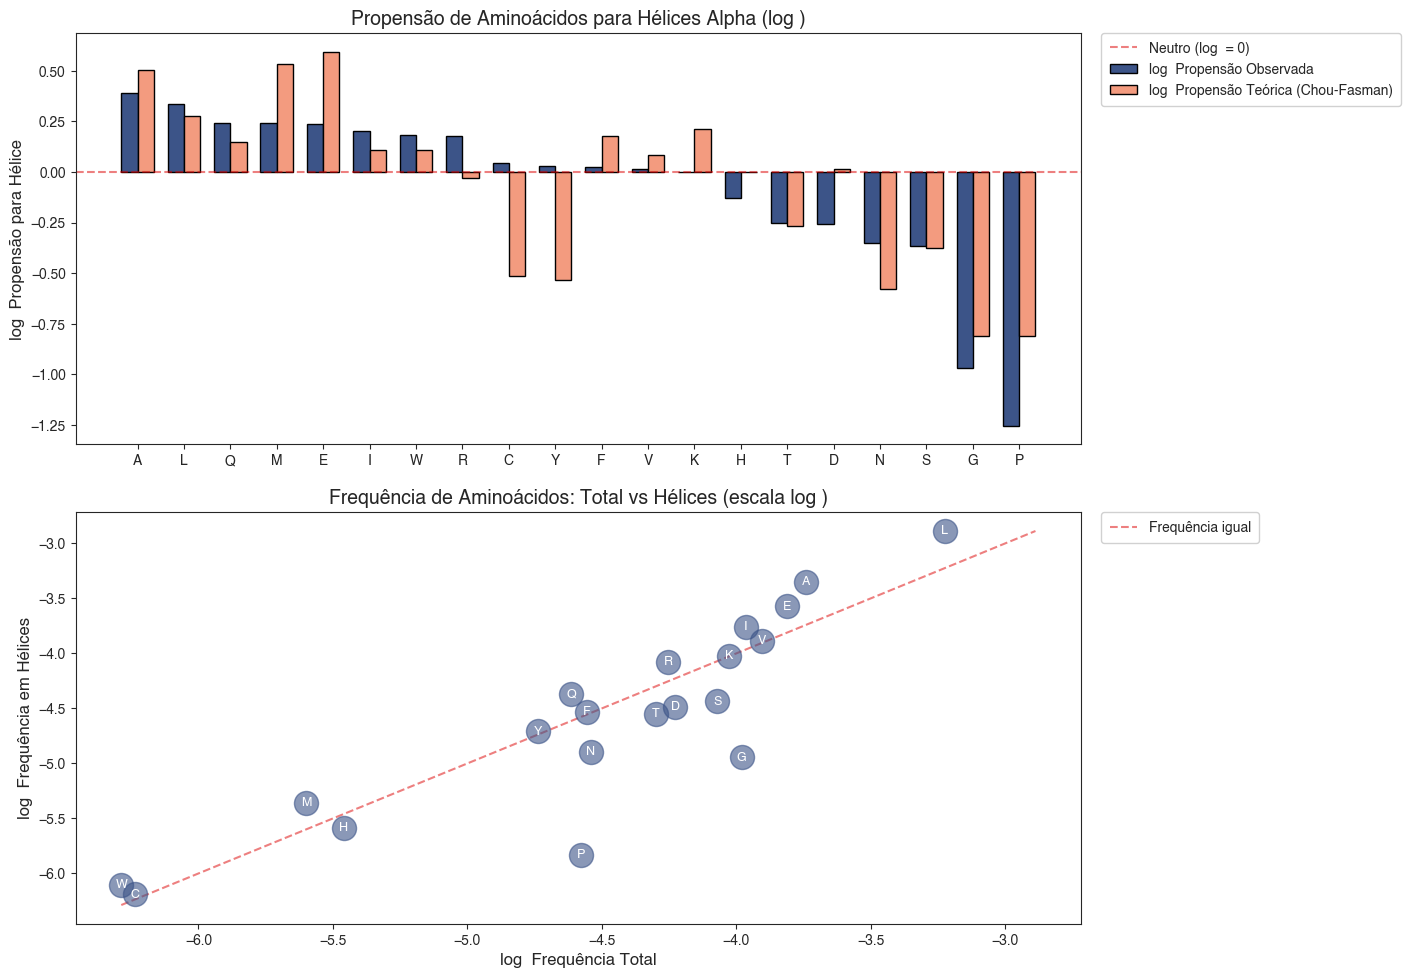

In [135]:
# ── Estilo ────────────────────────────────────────────────────────────────────
figsize       = (14, 10)
cor_obs       = COR_A
cor_teo       = COR_B
bar_width     = 0.35
bar_edge      = 'black'
scatter_size  = 300
scatter_alpha = 0.6
ref_color     = COR_REF
ref_style     = '--'

# ── Plot ──────────────────────────────────────────────────────────────────────
df  = propensity_df
x   = np.arange(len(df))
fig, axes = plt.subplots(2, 1, figsize=figsize)

log2_obs = np.log2(df['Propensity_Observed'].clip(lower=1e-10))
log2_teo = np.log2(df['Propensity_Theoretical'].clip(lower=1e-10))

axes[0].bar(x - bar_width/2, log2_obs, bar_width,
            label='log₂ Propensão Observada', color=cor_obs, edgecolor=bar_edge)
axes[0].bar(x + bar_width/2, log2_teo, bar_width,
            label='log₂ Propensão Teórica (Chou-Fasman)', color=cor_teo, edgecolor=bar_edge)
axes[0].axhline(0, color=ref_color, linestyle=ref_style, alpha=0.5, label='Neutro (log₂ = 0)')
axes[0].set_xticks(x); axes[0].set_xticklabels(df['AA'], rotation=0)
axes[0].set_ylabel('log₂ Propensão para Hélice')
axes[0].set_title('Propensão de Aminoácidos para Hélices Alpha (log₂)')
axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
axes[0].grid(axis='y', alpha=GRID_ALPHA)

freq_total_log = np.log2(df['Freq_Total'].clip(lower=1e-10) / 100)
freq_helix_log = np.log2(df['Freq_Helix'].clip(lower=1e-10) / 100)

axes[1].scatter(freq_total_log, freq_helix_log, s=scatter_size, alpha=scatter_alpha, color=cor_obs, zorder=5)
for _, row in df.iterrows():
    axes[1].text(np.log2(row['Freq_Total']/100), np.log2(row['Freq_Helix']/100), row['AA'],
                 ha='center', va='center', fontsize=FONT_ANNOT, fontweight='bold', color='white', zorder=6)
mn = min(freq_total_log.min(), freq_helix_log.min())
mx = max(freq_total_log.max(), freq_helix_log.max())
axes[1].plot([mn, mx], [mn, mx], color=ref_color, linestyle=ref_style, alpha=0.5, label='Frequência igual')
axes[1].set_xlabel('log₂ Frequência Total')
axes[1].set_ylabel('log₂ Frequência em Hélices')
axes[1].set_title('Frequência de Aminoácidos: Total vs Hélices (escala log₂)')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
axes[1].grid(alpha=GRID_ALPHA)

fig.tight_layout(pad=1.5)
fig.subplots_adjust(right=0.78)
fig.savefig(ANALYSIS / 'helix_propensities.png')
plt.show()

---
## Plot 2 — Preferência por Posição na Hélice (Heatmap)

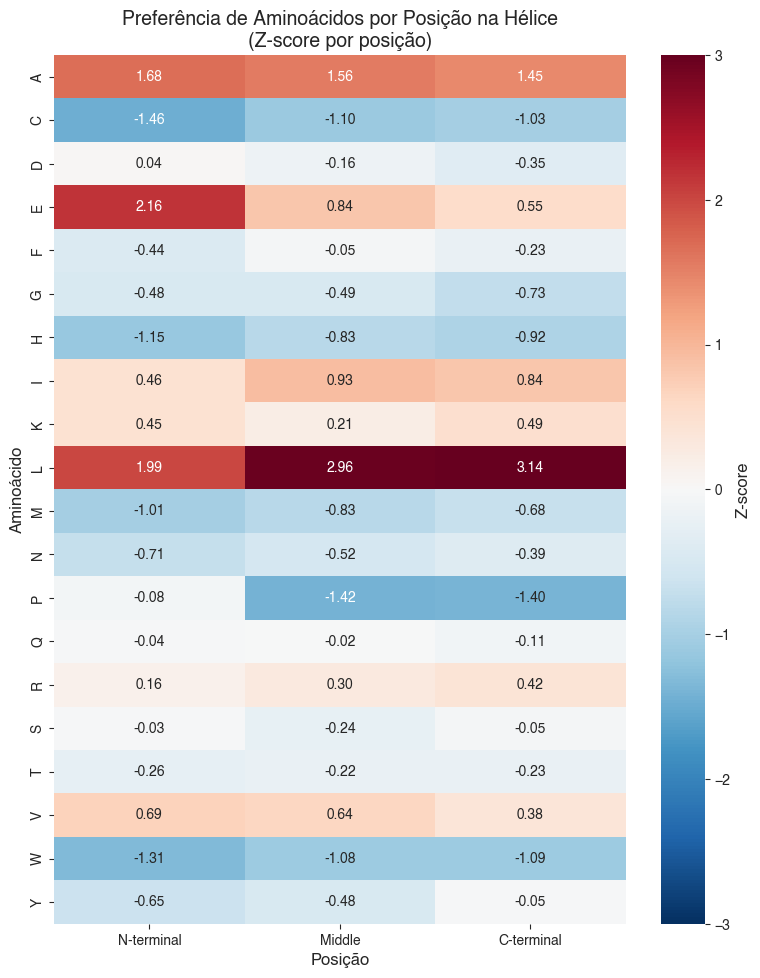

In [136]:
# ── Estilo ────────────────────────────────────────────────────────────────────
figsize   = (8, 10)
cmap      = 'RdBu_r'
annot_fmt = '.2f'

# ── Plot ──────────────────────────────────────────────────────────────────────
from scipy.stats import zscore as _zscore

pivot = positions_df.pivot(index='AA', columns='Position', values='Frequency')
pivot = pivot[['N-terminal', 'Middle', 'C-terminal']] / 100
pivot_z = pivot.apply(_zscore, axis=0)   # z-score por posição (coluna)

fig, ax = plt.subplots(figsize=figsize)
sns.heatmap(pivot_z, annot=True, fmt=annot_fmt, cmap=cmap, center=0, vmin=-3, vmax=3,
            cbar_kws={'label': 'Z-score'}, ax=ax)
ax.set_title('Preferência de Aminoácidos por Posição na Hélice\n(Z-score por posição)')
ax.set_ylabel('Aminoácido'); ax.set_xlabel('Posição')
fig.tight_layout(pad=1.5)
fig.savefig(ANALYSIS / 'helix_positions.png')
plt.show()

---
## Plot 3 — Distribuição de Comprimentos de Hélices (H/G/I)

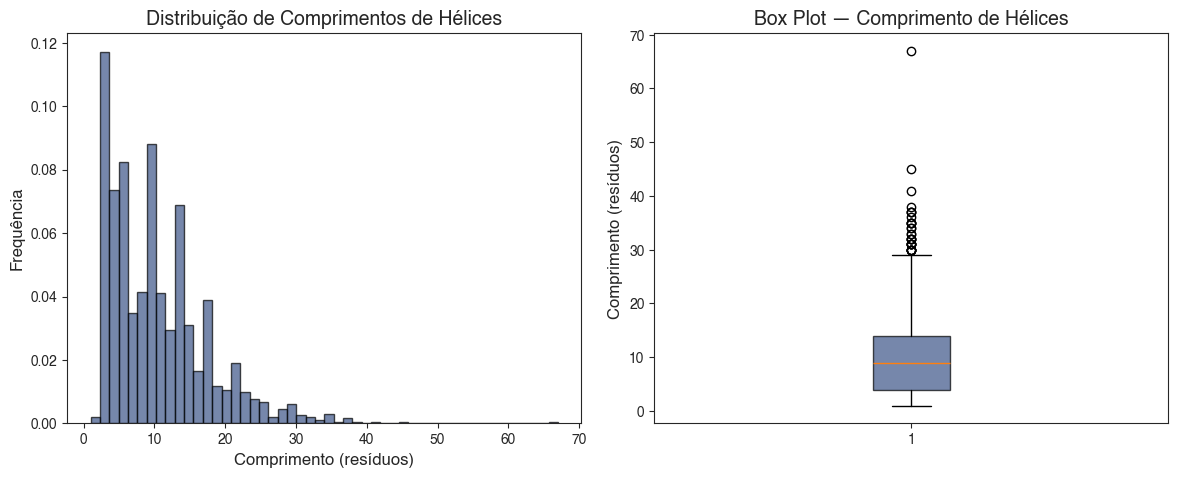

Média: 10.5  Mediana: 9.0  DP: 7.1  Mín/Máx: 1/67


In [137]:
# ── Estilo ────────────────────────────────────────────────────────────────────
figsize      = (12, 5)
bins         = 50
cor_hist     = COR_A
bar_edge     = 'black'
bar_alpha    = 0.7

# ── Dados ─────────────────────────────────────────────────────────────────────
all_lengths = (evo_data['helix_lengths_by_type']['H']
             + evo_data['helix_lengths_by_type']['G']
             + evo_data['helix_lengths_by_type']['I'])
arr = np.array(all_lengths)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=figsize)

axes[0].hist(arr, bins=bins, color=cor_hist, edgecolor=bar_edge, alpha=bar_alpha, density=True)
axes[0].set_xlabel('Comprimento (resíduos)'); axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição de Comprimentos de Hélices')
axes[0].grid(axis='y', alpha=GRID_ALPHA)

axes[1].boxplot(arr, vert=True, patch_artist=True,
                boxprops=dict(facecolor=cor_hist, alpha=0.7))
axes[1].set_ylabel('Comprimento (resíduos)')
axes[1].set_title('Box Plot — Comprimento de Hélices')
axes[1].grid(axis='y', alpha=GRID_ALPHA)

fig.tight_layout(pad=1.5)
fig.savefig(ANALYSIS / 'helix_lengths.png')
plt.show()
print(f'Média: {arr.mean():.1f}  Mediana: {np.median(arr):.1f}  DP: {arr.std():.1f}  Mín/Máx: {arr.min()}/{arr.max()}')

---
## Plot 4 — Padrao Heptad de Hidrofobicidade

/var/folders/_b/czss8ckx6dxfw7zkg7hg6fnm0000gn/T/ipykernel_49034/2244381464.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = [plt.cm.get_cmap(cmap)(norm(p)) for p in hydro_pcts]
/var/folders/_b/czss8ckx6dxfw7zkg7hg6fnm0000gn/T/ipykernel_49034/2244381464.py:49: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Helvetica.
  fig.tight_layout(pad=1.5)
/var/folders/_b/czss8ckx6dxfw7zkg7hg6fnm0000gn/T/ipykernel_49034/2244381464.py:50: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Helvetica.
  fig.savefig(ANALYSIS / 'heptad_pattern.png')
/Volumes/promethion/cath/debug/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Helvetica.
  fig.canvas.print_figure(bytes_io, **kw)


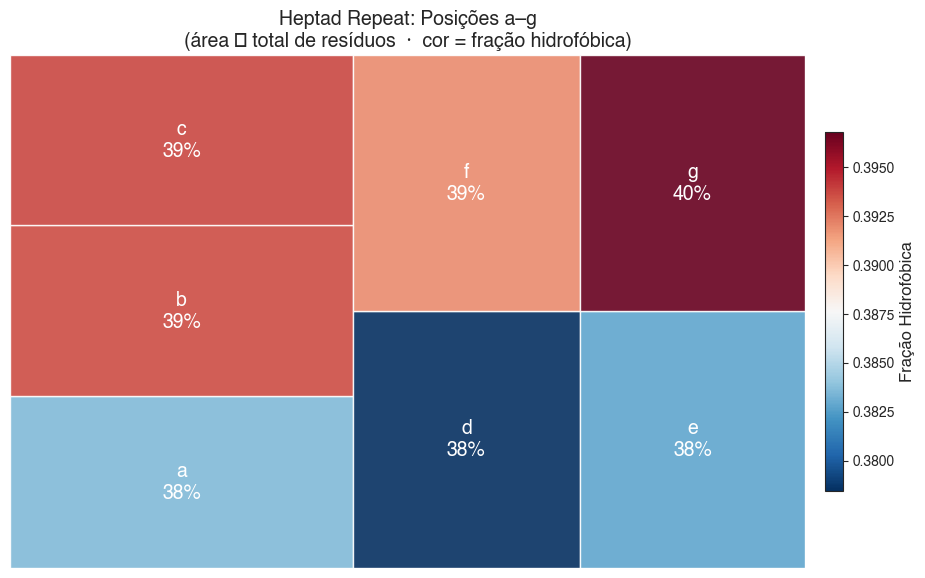

In [138]:
# ── Estilo ────────────────────────────────────────────────────────────────────
figsize = (10, 6)
cmap    = 'RdBu_r'   # vermelho = alta hidrofobicidade

# ── Dados ─────────────────────────────────────────────────────────────────────
import squarify
from cath_analysis.config import HYDROPHOBIC_AA, THREE_TO_ONE

HYDROPHOBIC_AA_1 = {THREE_TO_ONE[aa] for aa in HYDROPHOBIC_AA if aa in THREE_TO_ONE}

heptad_dist  = evo_data['heptad_aa_distribution']
labels_pos   = list('abcdefg')
total_counts = []
hydro_pcts   = []

for pos in range(7):
    cnts  = heptad_dist.get(pos, {})
    total = sum(cnts.values())
    hydro = sum(v for aa, v in cnts.items() if aa in HYDROPHOBIC_AA_1)
    total_counts.append(total)
    hydro_pcts.append(hydro / total if total > 0 else 0)

norm   = plt.Normalize(min(hydro_pcts), max(hydro_pcts))
colors = [plt.cm.get_cmap(cmap)(norm(p)) for p in hydro_pcts]
labels = [f'{l}\n{p:.0%}' for l, p in zip(labels_pos, hydro_pcts)]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=figsize)
squarify.plot(
    sizes=total_counts,
    label=labels,
    color=colors,
    alpha=0.9,
    ax=ax,
    text_kwargs={'fontsize': FONT_AXIS + 2, 'fontweight': 'bold', 'color': 'white'},
)
ax.axis('off')
ax.set_title(
    'Heptad Repeat: Posições a–g\n'
    '(área ∝ total de resíduos  ·  cor = fração hidrofóbica)',
    fontsize=FONT_TITLE, fontweight='bold',
)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', pad=0.02, shrink=0.7)
cbar.set_label('Fração Hidrofóbica', fontsize=FONT_AXIS)

fig.tight_layout(pad=1.5)
fig.savefig(ANALYSIS / 'heptad_pattern.png')
plt.show()

---
## Plot 4 — Distribuição de Tipos de Hélices (Bar + Pie)

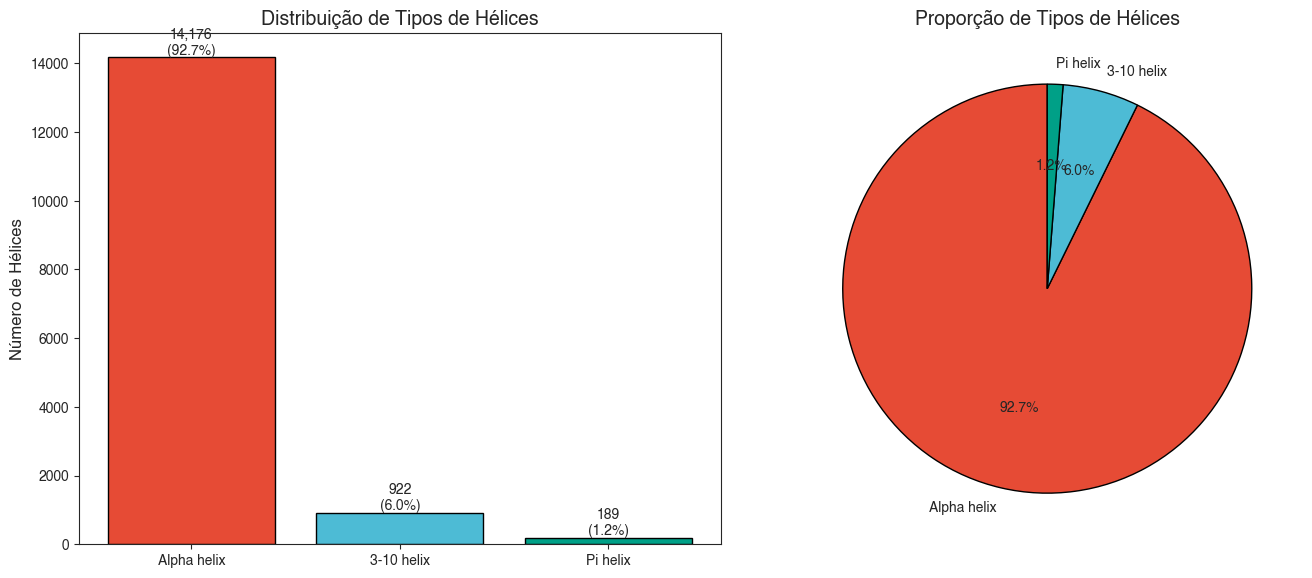

In [139]:
# ── Estilo ────────────────────────────────────────────────────────────────────
figsize  = (10, 6)
cores    = [COR_H, COR_G, COR_I]   # H, G, I

# ── Dados ─────────────────────────────────────────────────────────────────────
import squarify
from cath_analysis.config import HELIX_TYPES

counts_raw = composition_df.groupby('Helix_Type')['Count'].sum().to_dict()
ordered    = [(t, counts_raw[t]) for t in ('H', 'G', 'I') if t in counts_raw]
names      = [HELIX_TYPES[t] for t, _ in ordered]
counts     = [n for _, n in ordered]
total      = sum(counts)
pcts       = [c / total * 100 for c in counts]
colors     = cores[:len(ordered)]
labels     = [f'{name}\n{count:,}\n({pct:.1f}%)' for name, count, pct in zip(names, counts, pcts)]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=figsize)
squarify.plot(
    sizes=counts,
    label=labels,
    color=colors,
    alpha=0.9,
    ax=ax,
    text_kwargs={'fontsize': FONT_AXIS + 1, 'fontweight': 'bold', 'color': 'white'},
)
ax.axis('off')
ax.set_title('Distribuição de Tipos de Hélices\n(área \u221d número de hélices)',
             fontsize=FONT_TITLE, fontweight='bold')
fig.tight_layout(pad=1.5)
fig.savefig(ANALYSIS / 'helix_type_distribution.png')
plt.show()

---
## Plot 5 — Composição por Tipo de Hélice (Heatmap)

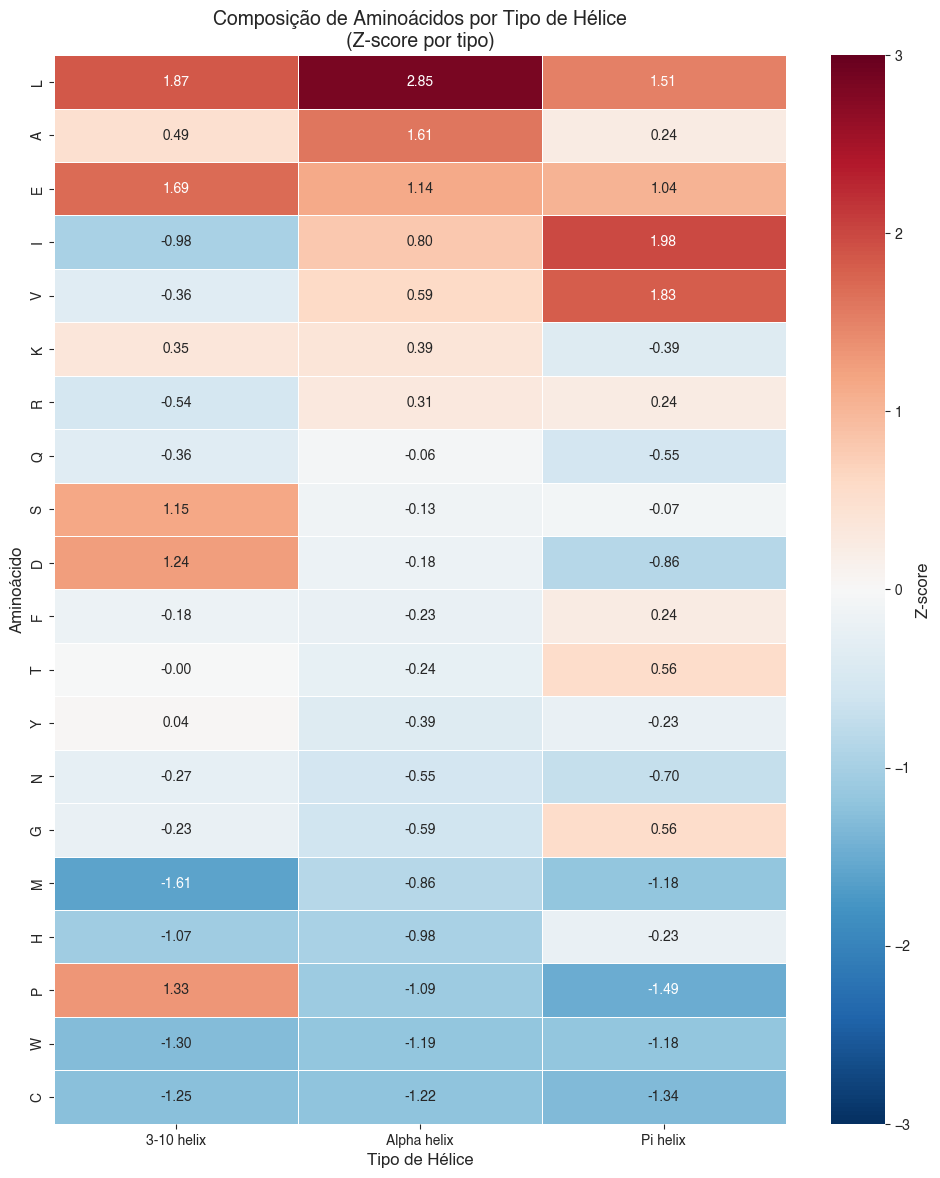

In [140]:
# ── Estilo ────────────────────────────────────────────────────────────────────
figsize     = (10, 12)
cmap        = 'RdBu_r'
annot_fmt   = '.2f'
line_widths = 0.5

# ── Plot ──────────────────────────────────────────────────────────────────────
from scipy.stats import zscore as _zscore

pivot = composition_df.pivot(index='AA', columns='Helix_Name', values='Frequency')
if 'Alpha helix' in pivot.columns:
    pivot = pivot.sort_values('Alpha helix', ascending=False)
pivot = pivot / 100
pivot_z = pivot.apply(_zscore, axis=0)   # z-score por tipo de hélice (coluna)

fig, ax = plt.subplots(figsize=figsize)
sns.heatmap(pivot_z, annot=True, fmt=annot_fmt, cmap=cmap, center=0, vmin=-3, vmax=3,
            cbar_kws={'label': 'Z-score'}, linewidths=line_widths, ax=ax)
ax.set_title('Composição de Aminoácidos por Tipo de Hélice\n(Z-score por tipo)', fontsize=FONT_TITLE, fontweight='bold')
ax.set_ylabel('Aminoácido'); ax.set_xlabel('Tipo de Hélice')
fig.tight_layout(pad=1.5)
fig.savefig(ANALYSIS / 'helix_type_composition_heatmap.png')
plt.show()

---
## Plot 6 — Top 10 Aminoácidos por Tipo de Hélice

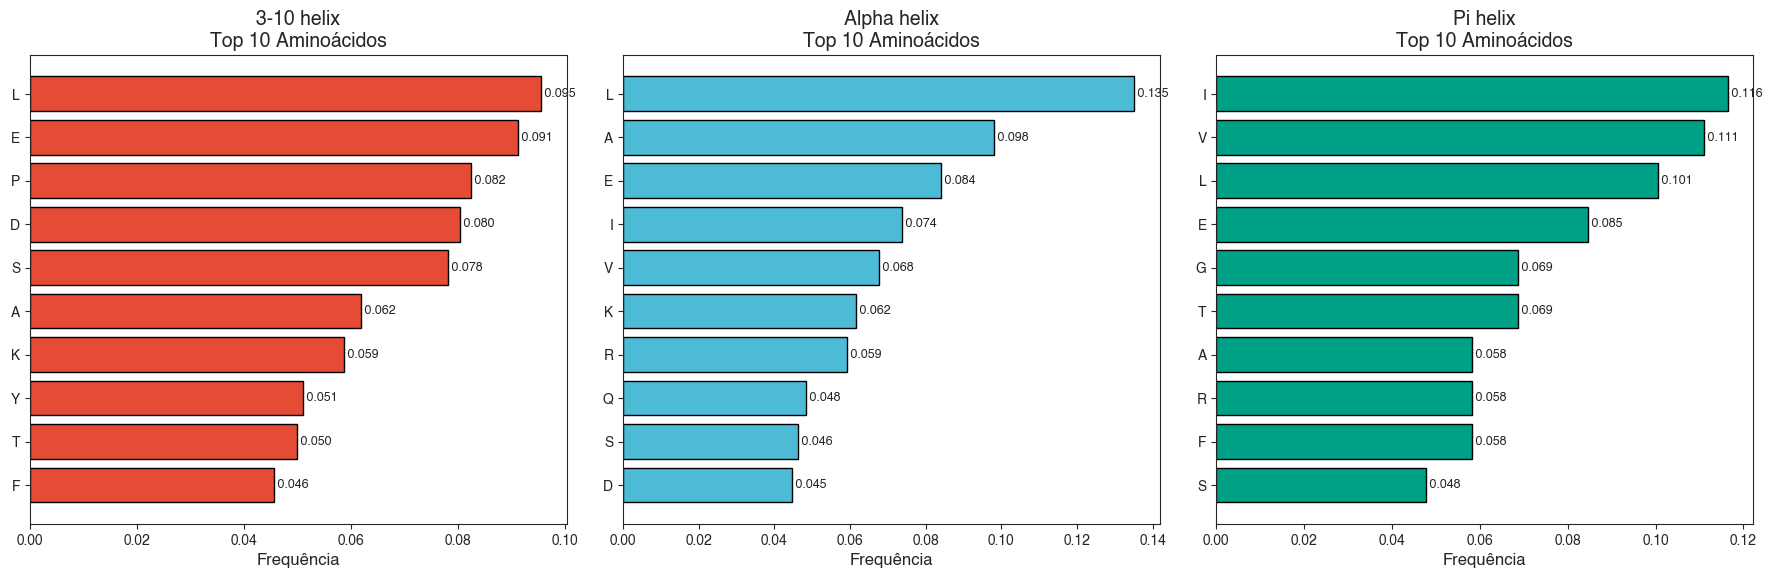

In [141]:
# ── Estilo ────────────────────────────────────────────────────────────────────
cores      = [COR_H, COR_G, COR_I]
bar_edge   = 'black'
top_n      = 10

# ── Plot ──────────────────────────────────────────────────────────────────────
helix_names = top_residues_df['Helix_Name'].unique()
n_types     = len(helix_names)

fig, axes = plt.subplots(1, n_types, figsize=(6 * n_types, 6))
if n_types == 1:
    axes = [axes]

for idx, h_name in enumerate(helix_names):
    data = top_residues_df[top_residues_df['Helix_Name'] == h_name].nsmallest(top_n, 'Rank')
    freqs_norm = data['Frequency'] / 100
    axes[idx].barh(data['AA'], freqs_norm, color=cores[idx % len(cores)], edgecolor=bar_edge)
    axes[idx].set_xlabel('Frequência'); axes[idx].invert_yaxis()
    axes[idx].set_title(f'{h_name}\nTop {top_n} Aminoácidos', fontweight='bold')
    axes[idx].grid(axis='x', alpha=GRID_ALPHA)
    for aa, freq in zip(data['AA'], freqs_norm):
        axes[idx].text(freq, aa, f' {freq:.3f}', va='center', fontsize=FONT_ANNOT)

fig.tight_layout(pad=1.5)
fig.savefig(ANALYSIS / 'helix_type_top_amino_acids.png')
plt.show()

---
## Plot 7 — Comparação Estatística Alpha vs 3-10

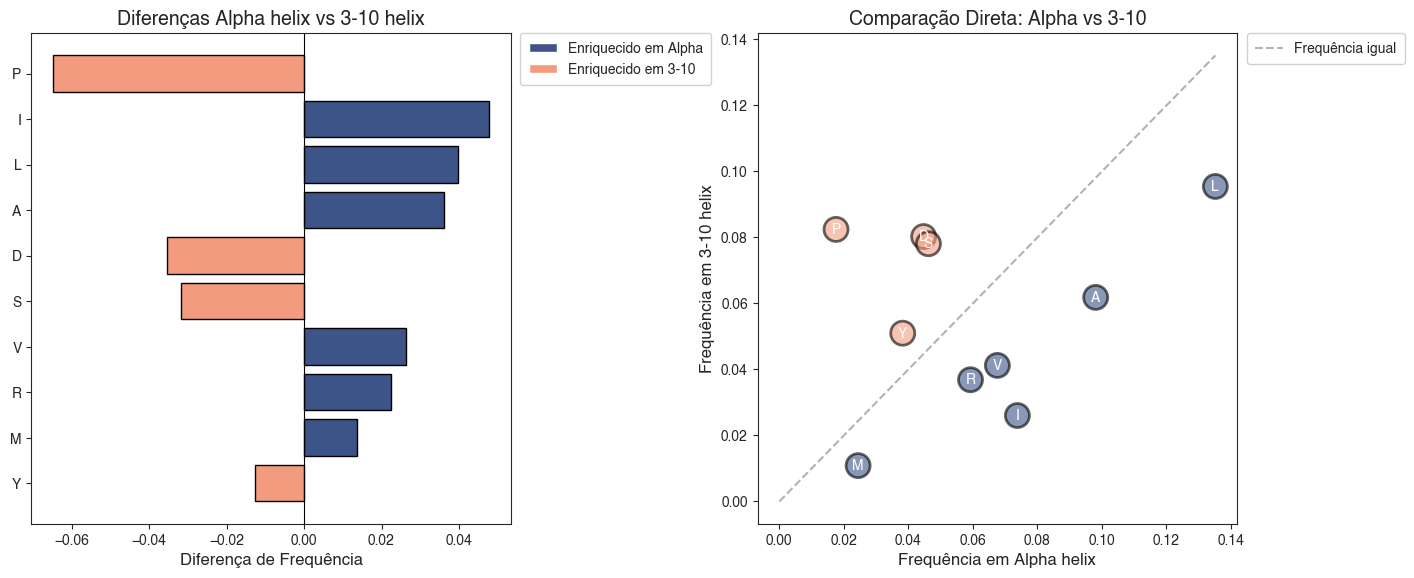

In [142]:
# ── Estilo ────────────────────────────────────────────────────────────────────
figsize       = (16, 6)
cor_alpha     = COR_A       # enriquecido em Alpha
cor_310       = COR_B       # enriquecido em 3-10
top_n         = 10
scatter_size  = 300
scatter_alpha = 0.6
lw_annot      = 2

# ── Plot ──────────────────────────────────────────────────────────────────────
top = stat_df.head(top_n)
diff_norm       = top['Difference'] / 100
alpha_freq_norm = top['Alpha_Freq'] / 100
freq_310_norm   = top['3-10_Freq'] / 100
colors = [cor_alpha if x > 0 else cor_310 for x in top['Difference']]

fig, axes = plt.subplots(1, 2, figsize=figsize)

axes[0].barh(top['AA'], diff_norm, color=colors, edgecolor='black')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Diferença de Frequência'); axes[0].invert_yaxis()
axes[0].set_title('Diferenças Alpha helix vs 3-10 helix', fontweight='bold')
axes[0].grid(axis='x', alpha=GRID_ALPHA)
axes[0].legend(handles=[Patch(facecolor=cor_alpha, label='Enriquecido em Alpha'),
                         Patch(facecolor=cor_310,   label='Enriquecido em 3-10')],
               bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

axes[1].scatter(alpha_freq_norm, freq_310_norm,
                s=scatter_size, alpha=scatter_alpha, c=colors, edgecolor='black', linewidth=lw_annot, zorder=5)
for _, row in top.iterrows():
    axes[1].text(row['Alpha_Freq']/100, row['3-10_Freq']/100, row['AA'],
                 ha='center', va='center', fontsize=FONT_TICK, fontweight='bold', color='white', zorder=6)
mx = max(alpha_freq_norm.max(), freq_310_norm.max())
axes[1].plot([0, mx], [0, mx], 'k--', alpha=0.3, label='Frequência igual')
axes[1].set_xlabel('Frequência em Alpha helix'); axes[1].set_ylabel('Frequência em 3-10 helix')
axes[1].set_title('Comparação Direta: Alpha vs 3-10', fontweight='bold')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
axes[1].grid(alpha=GRID_ALPHA)

fig.tight_layout(pad=1.5)
fig.subplots_adjust(right=0.78)
fig.savefig(ANALYSIS / 'helix_type_statistical_comparison.png')
plt.show()

---
## Plot 8 — Comprimento por Tipo de Hélice (Boxplot + Histograma)

/var/folders/_b/czss8ckx6dxfw7zkg7hg6fnm0000gn/T/ipykernel_49034/3497316215.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_list, labels=labels, patch_artist=True)


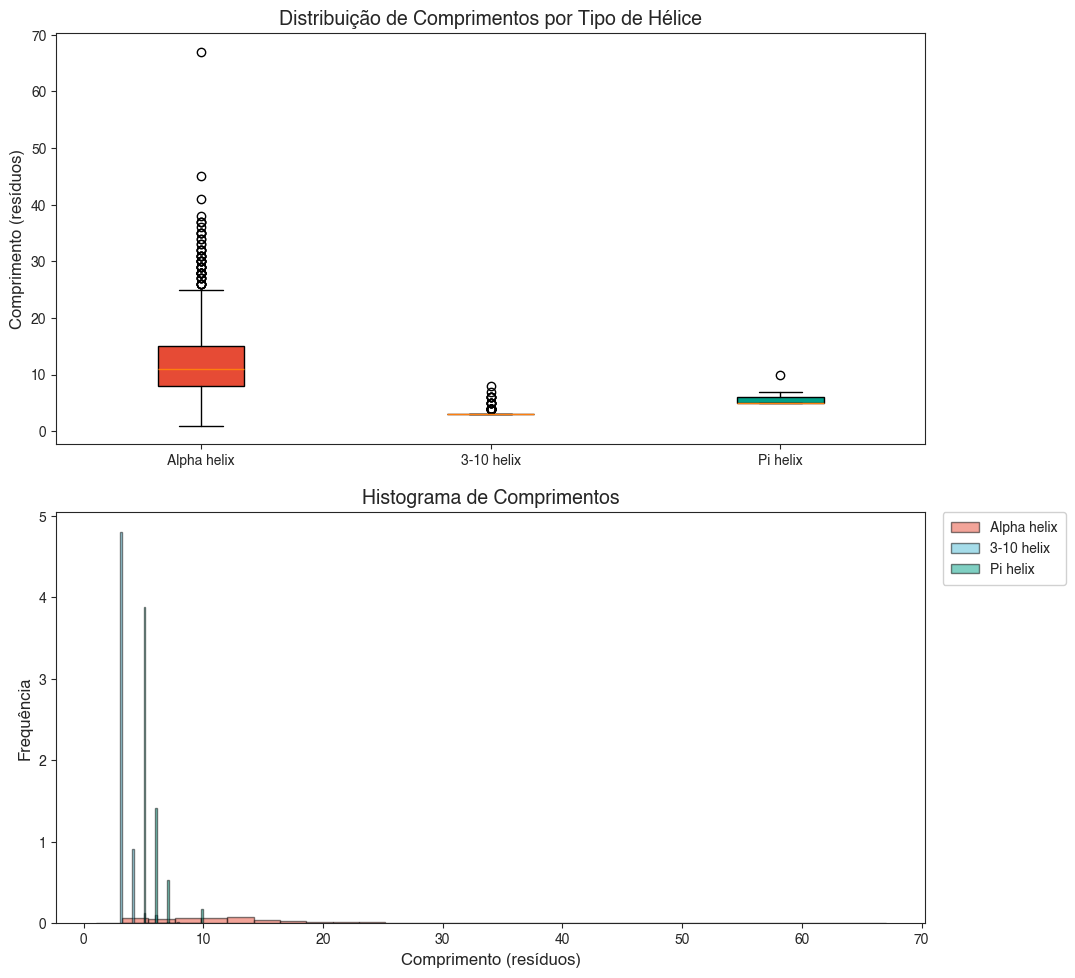

In [143]:
# ── Estilo ────────────────────────────────────────────────────────────────────
figsize   = (12, 10)
cores     = [COR_H, COR_G, COR_I]
bins      = 30
hist_alpha= 0.5

# ── Dados ─────────────────────────────────────────────────────────────────────
from cath_analysis.config import HELIX_TYPES
helix_lengths = evo_data['helix_lengths_by_type']
types_to_plot = [t for t in ('H', 'G', 'I') if helix_lengths.get(t)]
data_list     = [helix_lengths[t] for t in types_to_plot]
labels        = [HELIX_TYPES[t] for t in types_to_plot]
colors        = cores[:len(types_to_plot)]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=figsize)

bp = axes[0].boxplot(data_list, labels=labels, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[0].set_ylabel('Comprimento (resíduos)')
axes[0].set_title('Distribuição de Comprimentos por Tipo de Hélice')
axes[0].grid(axis='y', alpha=GRID_ALPHA)

for ht, color in zip(types_to_plot, colors):
    axes[1].hist(helix_lengths[ht], bins=bins, alpha=hist_alpha, density=True,
                 label=HELIX_TYPES[ht], color=color, edgecolor='black')
axes[1].set_xlabel('Comprimento (resíduos)'); axes[1].set_ylabel('Frequência')
axes[1].set_title('Histograma de Comprimentos')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
axes[1].grid(axis='y', alpha=GRID_ALPHA)

fig.tight_layout(pad=1.5)
fig.subplots_adjust(right=0.78)
fig.savefig(ANALYSIS / 'helix_length_by_type.png')
plt.show()

---
## Plot 9 — Helical Wheel Composto

/var/folders/_b/czss8ckx6dxfw7zkg7hg6fnm0000gn/T/ipykernel_49034/2693971647.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color=plt.cm.get_cmap(cmap)(freq), edgecolor='black', linewidth=0.5)


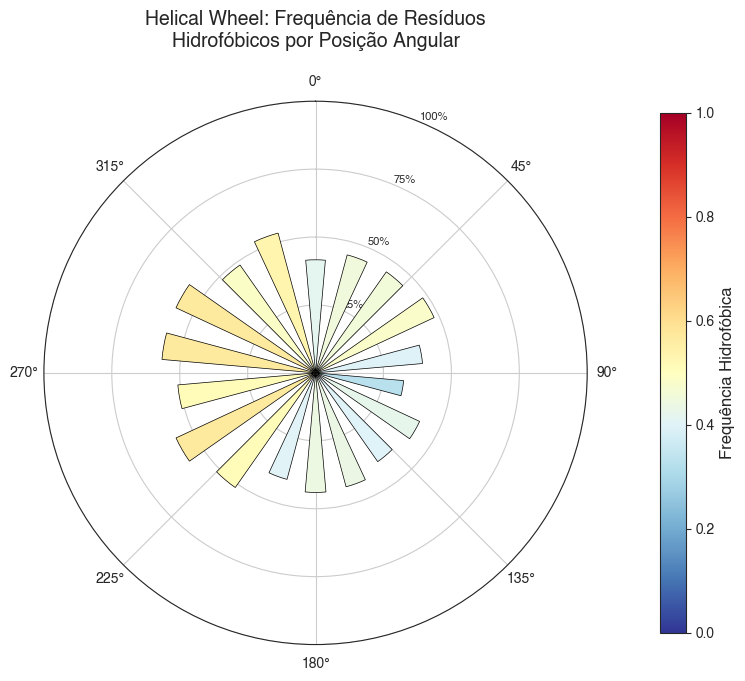

In [144]:
# ── Estilo ────────────────────────────────────────────────────────────────────
figsize   = (8, 8)
cmap      = 'RdYlBu_r'
n_bins    = 36        # bins de 10° cada
deg_step  = 100       # graus por resíduo na alfa-hélice

# ── Dados ─────────────────────────────────────────────────────────────────────
from cath_analysis.config import HYDROPHOBIC_AA, THREE_TO_ONE

# evo_data usa 1 letra → converte HYDROPHOBIC_AA para 1 letra
HYDROPHOBIC_AA_1 = {THREE_TO_ONE[aa] for aa in HYDROPHOBIC_AA if aa in THREE_TO_ONE}

angle_hydro = np.zeros(n_bins)
angle_total = np.zeros(n_bins)
for seq in evo_data['helix_sequences']:
    for i, aa in enumerate(seq):
        bin_idx = int(((i * deg_step) % 360) / (360 / n_bins))
        angle_total[bin_idx] += 1
        if aa in HYDROPHOBIC_AA_1:
            angle_hydro[bin_idx] += 1

with np.errstate(divide='ignore', invalid='ignore'):
    freq = np.where(angle_total > 0, angle_hydro / angle_total, 0)

angles = np.linspace(0, 2 * np.pi, n_bins, endpoint=False)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=figsize, subplot_kw={'projection': 'polar'})
ax.bar(angles, freq, width=2 * np.pi / n_bins,
       color=plt.cm.get_cmap(cmap)(freq), edgecolor='black', linewidth=0.5)
ax.set_theta_zero_location('N'); ax.set_theta_direction(-1)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=8)
ax.set_title('Helical Wheel: Frequência de Resíduos\nHidrofóbicos por Posição Angular',
             fontsize=FONT_TITLE, fontweight='bold', pad=20)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
sm.set_array([])
plt.colorbar(sm, ax=ax, pad=0.1, shrink=0.7, label='Frequência Hidrofóbica')
fig.tight_layout(pad=1.5)
fig.savefig(ANALYSIS / 'helical_wheel_average.png')
plt.show()

---
## Plot 10 — Momento Hidrofóbico de Eisenberg

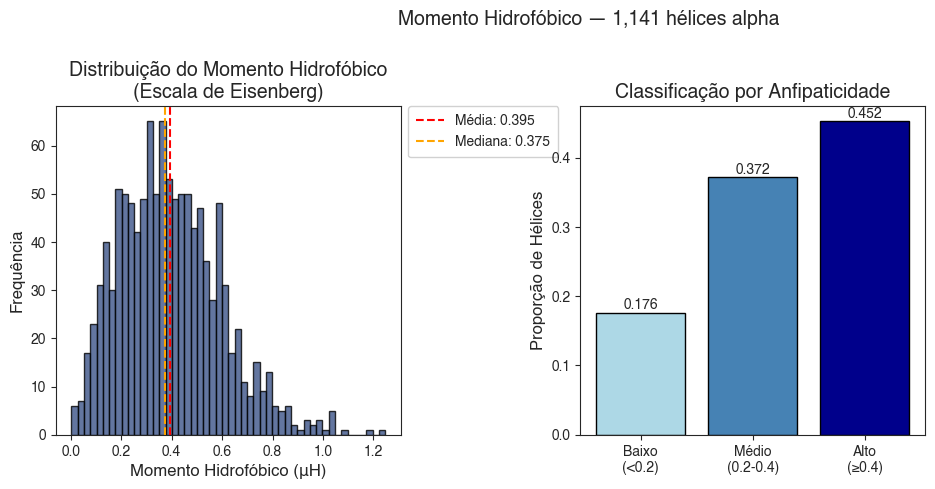

In [145]:
# ── Estilo ────────────────────────────────────────────────────────────────────
figsize       = (12, 5)
cor_hist      = COR_A
cor_media     = 'red'
cor_mediana   = 'orange'
bins          = 50
cores_bar     = ['lightblue', 'steelblue', 'darkblue']

# ── Plot ──────────────────────────────────────────────────────────────────────
arr = np.array(moments)
low = np.sum(arr < 0.2); med = np.sum((arr >= 0.2) & (arr < 0.4)); high = np.sum(arr >= 0.4)
total = len(arr)

fig, axes = plt.subplots(1, 2, figsize=figsize)

axes[0].hist(arr, bins=bins, color=cor_hist, edgecolor='black', alpha=0.8)
axes[0].axvline(arr.mean(),    color=cor_media,   linestyle='--', label=f'Média: {arr.mean():.3f}')
axes[0].axvline(np.median(arr),color=cor_mediana, linestyle='--', label=f'Mediana: {np.median(arr):.3f}')
axes[0].set_xlabel('Momento Hidrofóbico (μH)'); axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição do Momento Hidrofóbico\n(Escala de Eisenberg)')
axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
axes[0].grid(axis='y', alpha=GRID_ALPHA)

vals = [low/total, med/total, high/total]
axes[1].bar(['Baixo\n(<0.2)', 'Médio\n(0.2-0.4)', 'Alto\n(≥0.4)'], vals,
            color=cores_bar, edgecolor='black')
axes[1].set_ylabel('Proporção de Hélices'); axes[1].set_title('Classificação por Anfipaticidade')
axes[1].grid(axis='y', alpha=GRID_ALPHA)
for i, v in enumerate(vals):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')

fig.suptitle(f'Momento Hidrofóbico — {total:,} hélices alpha', fontsize=FONT_TITLE, fontweight='bold')
fig.tight_layout(pad=1.5)
fig.subplots_adjust(right=0.78)
fig.savefig(ANALYSIS / 'hydrophobic_moment_distribution.png')
plt.show()

---
## Plot 11 — N-cap / C-cap (Preferência de Aminoácidos)

IndexError: Inconsistent shape between the condition and the input (got (3, 1) and (3,))

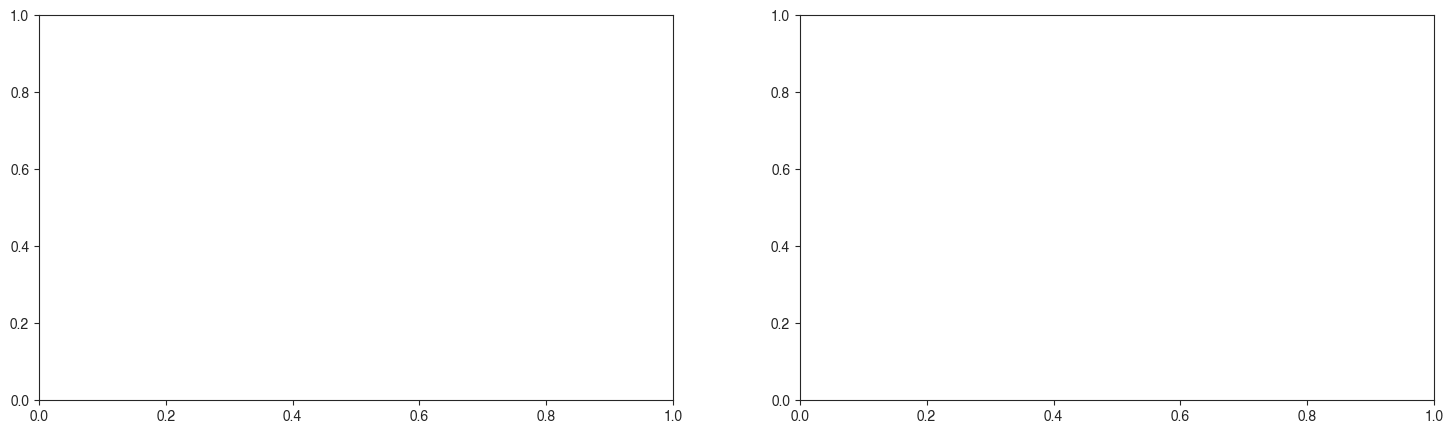

In [146]:
# ── Estilo ────────────────────────────────────────────────────────────────────
figsize     = (18, 5)
cmap_ncap   = 'RdBu_r'
cmap_ccap   = 'RdBu_r'
annot_fmt   = '.2f'
line_widths = 0.3

# ── Dados ─────────────────────────────────────────────────────────────────────
from cath_analysis.config import THREE_TO_ONE
from scipy.stats import zscore as _zscore

all_aa = sorted(THREE_TO_ONE.values())

def _to_freq(pos_dict, positions):
    rows = {}
    for p in positions:
        cnts = pos_dict.get(p, {})
        total = sum(cnts.values()) or 1
        rows[str(p)] = {aa: cnts.get(aa, 0) / total for aa in all_aa}
    return pd.DataFrame(rows, index=all_aa).T

ncap_df = _to_freq(evo_data['ncap_position'], [0, 1, 2])
ccap_df = _to_freq(evo_data['ccap_position'], [-3, -2, -1])
ncap_df.index = ['N1', 'N2', 'N3']
ccap_df.index = ['C3', 'C2', 'C1']

# Z-score por posição (linha → ao longo dos AAs)
ncap_z = ncap_df.apply(_zscore, axis=1)
ccap_z = ccap_df.apply(_zscore, axis=1)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=figsize)

sns.heatmap(ncap_z, annot=True, fmt=annot_fmt, cmap=cmap_ncap, center=0, vmin=-3, vmax=3,
            cbar_kws={'label': 'Z-score'}, linewidths=line_widths, ax=axes[0])
axes[0].set_title('N-cap: Enriquecimento de Aminoácidos\n(Z-score, posições N1, N2, N3)', fontweight='bold')
axes[0].set_xlabel('Aminoácido'); axes[0].set_ylabel('Posição')

sns.heatmap(ccap_z, annot=True, fmt=annot_fmt, cmap=cmap_ccap, center=0, vmin=-3, vmax=3,
            cbar_kws={'label': 'Z-score'}, linewidths=line_widths, ax=axes[1])
axes[1].set_title('C-cap: Enriquecimento de Aminoácidos\n(Z-score, posições C3, C2, C1)', fontweight='bold')
axes[1].set_xlabel('Aminoácido'); axes[1].set_ylabel('Posição')

fig.tight_layout(pad=1.5)
fig.savefig(ANALYSIS / 'ncap_ccap_preferences.png')
plt.show()

---
## Plot 12 — PCA da Composição por Estrutura

/var/folders/_b/czss8ckx6dxfw7zkg7hg6fnm0000gn/T/ipykernel_49034/2890179865.py:49: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  markerfacecolor=plt.cm.get_cmap(cmap)(i / 20),


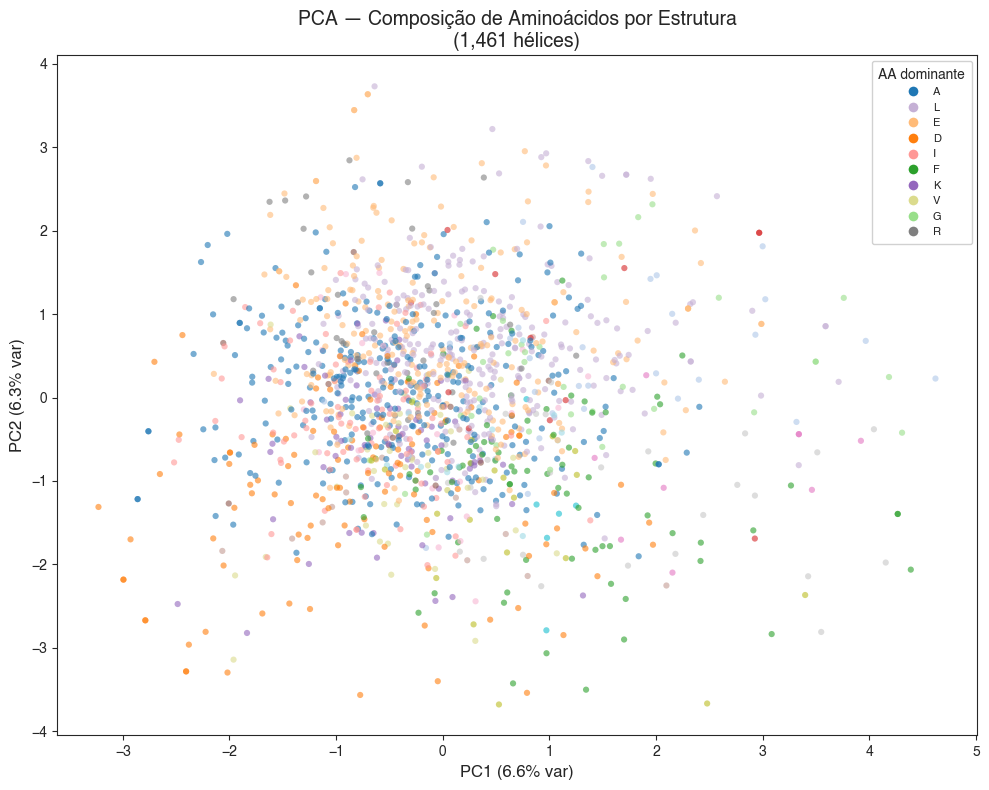

In [ ]:
# ── Estilo ────────────────────────────────────────────────────────────────────
figsize       = (10, 8)
cmap          = 'tab20'
point_size    = 20
point_alpha   = 0.6
top_legend    = 10   # top N AAs dominantes na legenda

# ── Dados ─────────────────────────────────────────────────────────────────────
from collections import Counter
from cath_analysis.config import THREE_TO_ONE
try:
    from sklearn.preprocessing import StandardScaler
    from sklearn.decomposition import PCA
except ImportError:
    raise ImportError('Instale scikit-learn: pip install scikit-learn')

# evo_data usa 1 letra → usa 1 letra como features
all_aa = sorted(THREE_TO_ONE.values())

per_structure: dict[int, Counter] = {}
for i, helix in enumerate(evo_data['per_helix_data']):
    per_structure.setdefault(i, Counter()).update(helix['aa_counts'])

codes  = sorted(per_structure.keys())
matrix = []
for code in codes:
    cnts  = per_structure[code]
    total = sum(cnts.values()) or 1
    matrix.append([cnts.get(aa, 0) / total for aa in all_aa])

X        = np.array(matrix)
X_scaled = StandardScaler().fit_transform(X)
pca      = PCA(n_components=2, random_state=42)
coords   = pca.fit_transform(X_scaled)
dom_idx  = X.argmax(axis=1)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=figsize)
ax.scatter(coords[:, 0], coords[:, 1], c=dom_idx,
           cmap=cmap, alpha=point_alpha, s=point_size, edgecolors='none')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title(f'PCA — Composição de Aminoácidos por Estrutura\n({len(codes):,} hélices)')
ax.grid(alpha=GRID_ALPHA)

unique, cnts_dom = np.unique(dom_idx, return_counts=True)
top_idx = unique[np.argsort(-cnts_dom)[:top_legend]]
handles = [plt.Line2D([0], [0], marker='o', color='w',
                       markerfacecolor=plt.cm.get_cmap(cmap)(i / 20),
                       markersize=8, label=all_aa[i]) for i in top_idx]
ax.legend(handles=handles, title='AA dominante', loc='best', fontsize=8)
fig.tight_layout(pad=1.5)
fig.savefig(ANALYSIS / 'pca_aa_composition.png')
plt.show()

---
## Plot 13 — Conteúdo Helicoidal por Estrutura

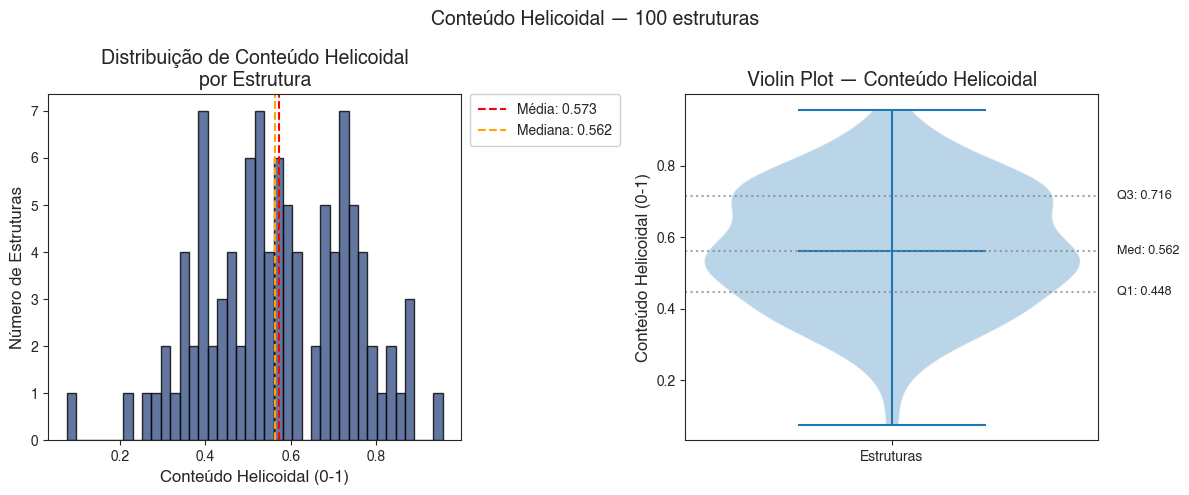

In [ ]:
# ── Estilo ────────────────────────────────────────────────────────────────────
figsize     = (12, 5)
cor_hist    = COR_A
cor_media   = 'red'
cor_mediana = 'orange'
bins        = 40

# ── Plot ──────────────────────────────────────────────────────────────────────
arr = np.array(evo_data['helix_content_per_structure'])

fig, axes = plt.subplots(1, 2, figsize=figsize)

axes[0].hist(arr, bins=bins, color=cor_hist, edgecolor='black', alpha=0.8)
axes[0].axvline(arr.mean(),    color=cor_media,   linestyle='--', label=f'Média: {arr.mean():.3f}')
axes[0].axvline(np.median(arr),color=cor_mediana, linestyle='--', label=f'Mediana: {np.median(arr):.3f}')
axes[0].set_xlabel('Conteúdo Helicoidal (0-1)'); axes[0].set_ylabel('Número de Estruturas')
axes[0].set_title('Distribuição de Conteúdo Helicoidal\npor Estrutura')
axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
axes[0].grid(axis='y', alpha=GRID_ALPHA)

axes[1].violinplot(arr, showmedians=True, showextrema=True)
axes[1].set_xticks([1]); axes[1].set_xticklabels(['Estruturas'])
axes[1].set_ylabel('Conteúdo Helicoidal (0-1)')
axes[1].set_title('Violin Plot — Conteúdo Helicoidal')
axes[1].grid(axis='y', alpha=GRID_ALPHA)
for p, label in [(25, 'Q1'), (50, 'Med'), (75, 'Q3')]:
    val = np.percentile(arr, p)
    axes[1].axhline(val, color='gray', linestyle=':', alpha=0.7)
    axes[1].text(1.3, val, f'{label}: {val:.3f}', va='center', fontsize=FONT_ANNOT)

fig.suptitle(f'Conteúdo Helicoidal — {len(arr):,} estruturas', fontsize=FONT_TITLE, fontweight='bold')
fig.tight_layout(pad=1.5)
fig.subplots_adjust(right=0.78)
fig.savefig(ANALYSIS / 'helix_content_distribution.png')
plt.show()

---
## Plot 14 — Co-ocorrência de Aminoácidos em Hélices

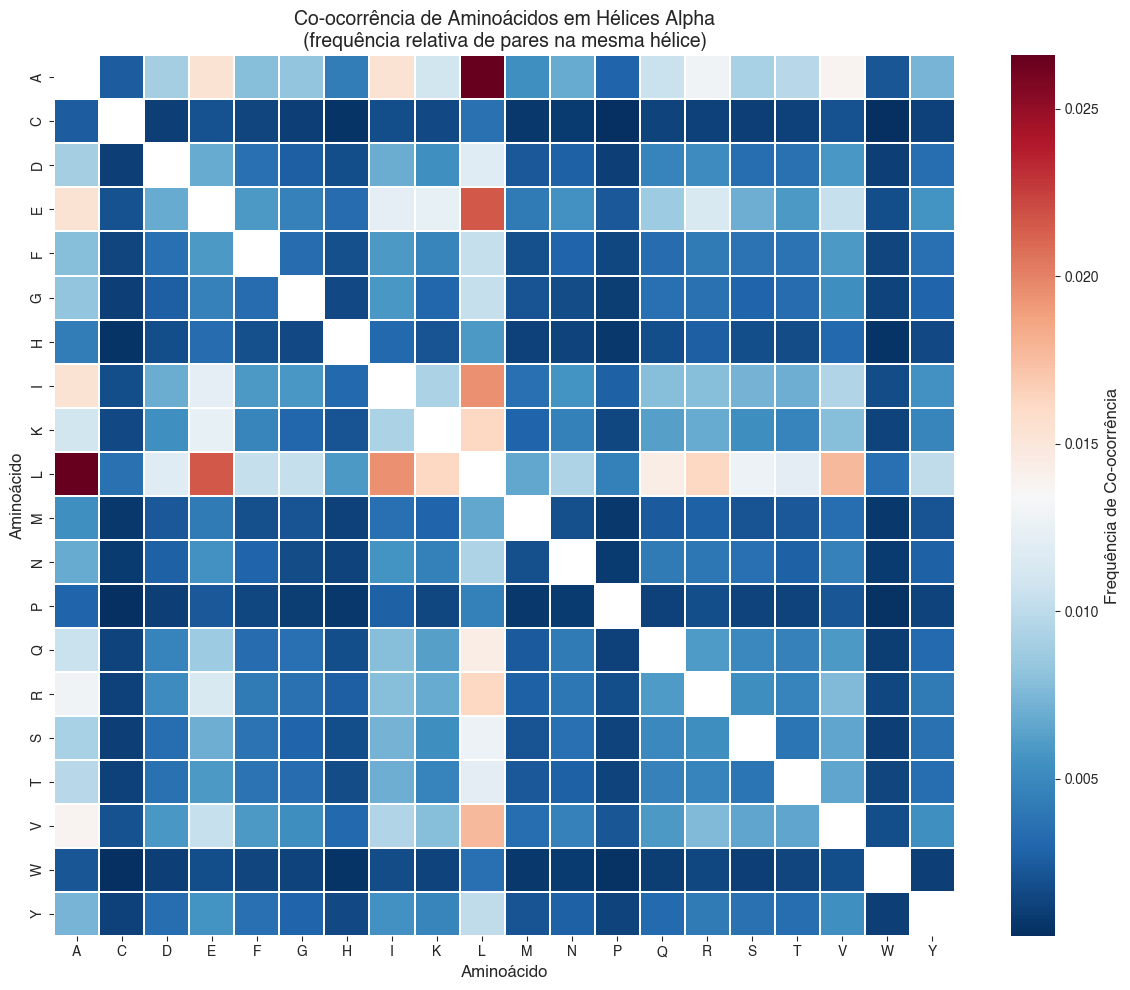

In [ ]:
# ── Estilo ────────────────────────────────────────────────────────────────────
figsize     = (12, 10)
cmap        = 'RdBu_r'
line_widths = 0.2

# ── Plot ──────────────────────────────────────────────────────────────────────
from scipy.stats import zscore as _zscore

cooc_z = cooc_df.apply(_zscore, axis=0)   # z-score por coluna
mask   = np.eye(len(cooc_z), dtype=bool)

fig, ax = plt.subplots(figsize=figsize)
sns.heatmap(cooc_z, annot=False, cmap=cmap, center=0, vmin=-3, vmax=3, mask=mask,
            cbar_kws={'label': 'Z-score de Co-ocorrência'}, linewidths=line_widths, ax=ax)
ax.set_title('Co-ocorrência de Aminoácidos em Hélices Alpha\n'
             '(Z-score — desvio relativo à média de co-ocorrência)',
             fontsize=FONT_TITLE, fontweight='bold')
ax.set_xlabel('Aminoácido'); ax.set_ylabel('Aminoácido')
fig.tight_layout(pad=1.5)
fig.savefig(ANALYSIS / 'aa_cooccurrence.png')
plt.show()

---
## Plot 15 — Composição por Comprimento de Hélice

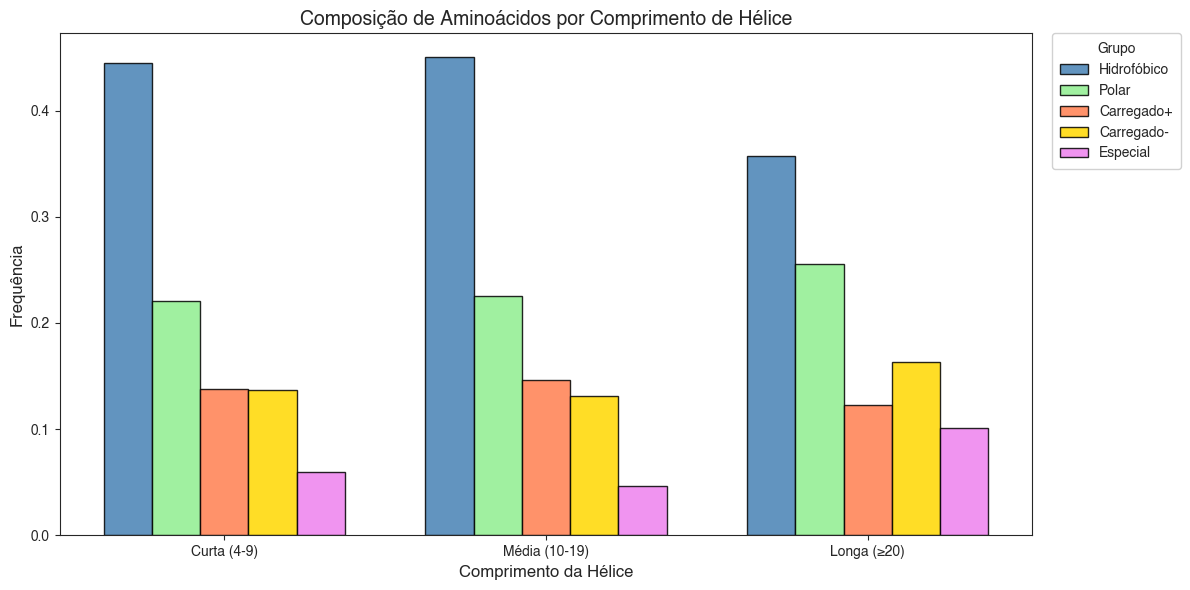

In [ ]:
# ── Estilo ────────────────────────────────────────────────────────────────────
figsize    = (12, 6)
bar_alpha  = 0.85
bar_edge   = 'black'
cores_grupo = {
    'Hidrofóbico': 'steelblue', 'Polar': 'lightgreen',
    'Carregado+'  : 'coral',     'Carregado-': 'gold', 'Especial': 'violet'
}

# ── Plot ──────────────────────────────────────────────────────────────────────
bins_order = ['Curta (4-9)', 'Média (10-19)', 'Longa (≥20)']
groups     = length_comp_df['Group'].unique()
x          = np.arange(len(bins_order))
width      = 0.15

fig, ax = plt.subplots(figsize=figsize)
for i, group in enumerate(groups):
    data  = length_comp_df[length_comp_df['Group'] == group]
    freqs = [data[data['Bin'] == b]['Frequency'].values[0]
             if len(data[data['Bin'] == b]) > 0 else 0
             for b in bins_order]
    freqs_norm = [f / 100 for f in freqs]
    offset = (i - len(groups)/2 + 0.5) * width
    ax.bar(x + offset, freqs_norm, width, label=group,
           color=cores_grupo.get(group, 'gray'), edgecolor=bar_edge, alpha=bar_alpha)

ax.set_xlabel('Comprimento da Hélice'); ax.set_ylabel('Frequência')
ax.set_title('Composição de Aminoácidos por Comprimento de Hélice')
ax.set_xticks(x); ax.set_xticklabels(bins_order)
ax.legend(title='Grupo', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
ax.grid(axis='y', alpha=GRID_ALPHA)
fig.tight_layout(pad=1.5)
fig.subplots_adjust(right=0.78)
fig.savefig(ANALYSIS / 'helix_length_vs_composition.png')
plt.show()

---
## Plot 16 — Matriz de Transição entre Tipos de Hélice

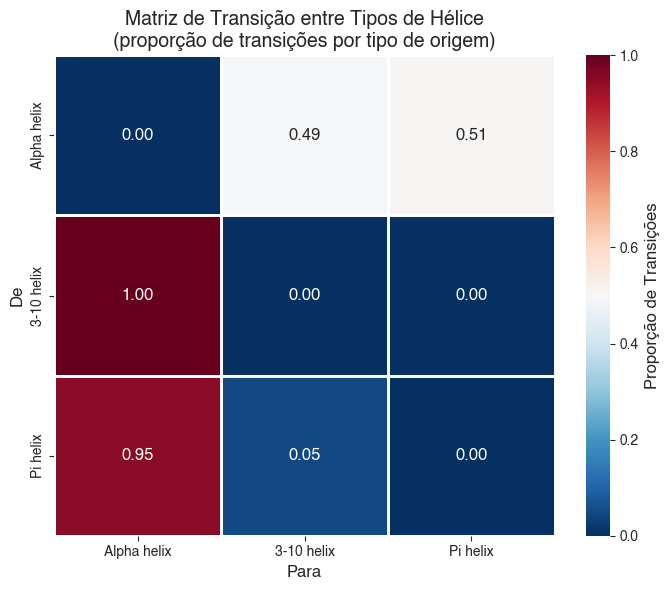

In [ ]:
# ── Estilo ────────────────────────────────────────────────────────────────────
figsize     = (7, 6)
cmap        = 'RdBu_r'
annot_fmt   = '.2f'
annot_size  = FONT_AXIS
line_widths = 1

# ── Dados ─────────────────────────────────────────────────────────────────────
from cath_analysis.config import HELIX_TYPES

all_types  = ['H', 'G', 'I']
matrix     = pd.DataFrame(0.0, index=all_types, columns=all_types)
for (src, dst), count in evo_data['transitions'].items():
    if src in all_types and dst in all_types:
        matrix.loc[src, dst] = count

row_sums    = matrix.sum(axis=1)
matrix_norm = matrix.div(row_sums.replace(0, 1), axis=0)
matrix_norm.index   = [HELIX_TYPES[t] for t in all_types]
matrix_norm.columns = [HELIX_TYPES[t] for t in all_types]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=figsize)
sns.heatmap(matrix_norm, annot=True, fmt=annot_fmt, cmap=cmap, vmin=0, vmax=1,
            cbar_kws={'label': 'Proporção de Transições'}, linewidths=line_widths,
            annot_kws={'size': annot_size, 'weight': 'bold'}, ax=ax)
ax.set_title('Matriz de Transição entre Tipos de Hélice\n'
             '(proporção de transições por tipo de origem)', fontsize=FONT_TITLE, fontweight='bold')
ax.set_xlabel('Para'); ax.set_ylabel('De')
fig.tight_layout(pad=1.5)
fig.savefig(ANALYSIS / 'helix_transition_matrix.png')
plt.show()

---
## Plot 17 — Razão 3-10 por Comprimento

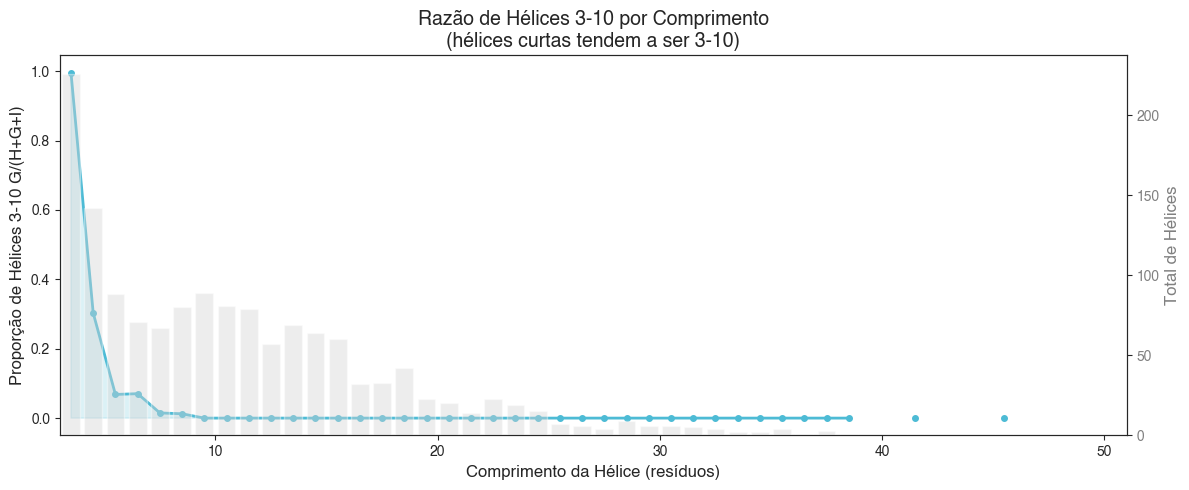

In [ ]:
# ── Estilo ────────────────────────────────────────────────────────────────────
figsize    = (12, 5)
cor_linha  = COR_G         # cor da linha 3-10
cor_area   = COR_G
area_alpha = 0.2
max_len_plot = 50          # comprimento máximo no eixo x

# ── Dados ─────────────────────────────────────────────────────────────────────
hlengths = evo_data['helix_lengths_by_type']
h_len = hlengths.get('H', []); g_len = hlengths.get('G', []); i_len = hlengths.get('I', [])

all_l = list(h_len) + list(g_len) + list(i_len)
max_l = min(max(all_l), max_len_plot)
bins  = list(range(3, max_l + 2))

h_c = np.histogram(h_len, bins=bins)[0] if h_len else np.zeros(len(bins)-1)
g_c = np.histogram(g_len, bins=bins)[0] if g_len else np.zeros(len(bins)-1)
i_c = np.histogram(i_len, bins=bins)[0] if i_len else np.zeros(len(bins)-1)
total = h_c + g_c + i_c

with np.errstate(divide='ignore', invalid='ignore'):
    g_ratio = np.where(total > 0, g_c / total, np.nan)

bin_centers = [(bins[i] + bins[i+1]) / 2 for i in range(len(bins)-1)]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=figsize)
ax.plot(bin_centers, g_ratio, 'o-', color=cor_linha, linewidth=2, markersize=4)
ax.fill_between(bin_centers, 0, g_ratio, alpha=area_alpha, color=cor_area)
ax.set_xlabel('Comprimento da Hélice (resíduos)')
ax.set_ylabel('Proporção de Hélices 3-10 G/(H+G+I)')
ax.set_title('Razão de Hélices 3-10 por Comprimento\n(hélices curtas tendem a ser 3-10)')
ax.grid(alpha=GRID_ALPHA); ax.set_xlim(bins[0], bins[-1])

ax2 = ax.twinx()
ax2.bar(bin_centers, total, width=0.8, color='lightgray', alpha=0.4, label='Total de hélices')
ax2.set_ylabel('Total de Hélices', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

fig.tight_layout(pad=1.5)
fig.savefig(ANALYSIS / 'g_ratio_by_length.png')
plt.show()

---
## Plot 18 — Entropia de Shannon por Posição no Heptad

/var/folders/_b/czss8ckx6dxfw7zkg7hg6fnm0000gn/T/ipykernel_49034/2524243589.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(cmap)(entropy_df['Entropy'] / entropy_df['Entropy'].max())


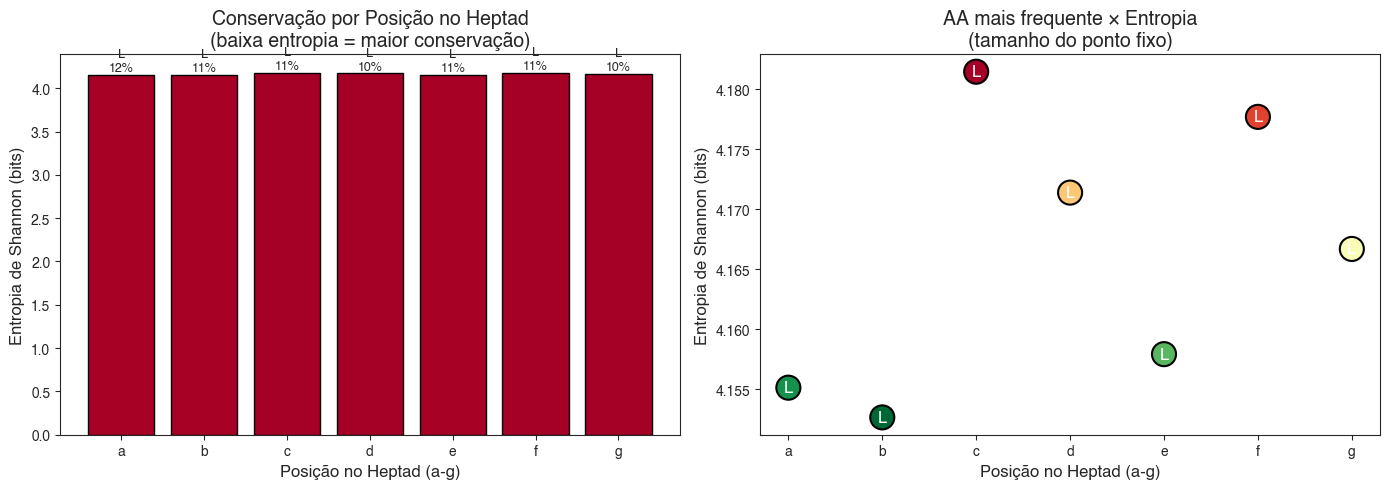

In [ ]:
# ── Estilo ────────────────────────────────────────────────────────────────────
figsize       = (14, 5)
cmap          = 'RdYlGn_r'  # baixa entropia (conservado) = verde
scatter_scale = 300          # tamanho base do ponto

# ── Plot ──────────────────────────────────────────────────────────────────────
colors = plt.cm.get_cmap(cmap)(entropy_df['Entropy'] / entropy_df['Entropy'].max())

fig, axes = plt.subplots(1, 2, figsize=figsize)

bars = axes[0].bar(entropy_df['Position'], entropy_df['Entropy'],
                   color=colors, edgecolor='black')
axes[0].set_xlabel('Posição no Heptad (a-g)')
axes[0].set_ylabel('Entropia de Shannon (bits)')
axes[0].set_title('Conservação por Posição no Heptad\n(baixa entropia = maior conservação)')
axes[0].grid(axis='y', alpha=GRID_ALPHA)
for bar, (_, row) in zip(bars, entropy_df.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{row['Top_AA']}\n{row['Top_Freq']:.0f}%",
                 ha='center', va='bottom', fontsize=FONT_ANNOT, fontweight='bold')

sc = axes[1].scatter(entropy_df['Position'], entropy_df['Entropy'],
                     s=scatter_scale,
                     c=entropy_df['Entropy'], cmap=cmap, edgecolors='black', linewidth=1.5, zorder=5)
for _, row in entropy_df.iterrows():
    axes[1].text(row['Position'], row['Entropy'], row['Top_AA'],
                 ha='center', va='center', fontsize=FONT_AXIS, fontweight='bold', color='white', zorder=6)
axes[1].set_xlabel('Posição no Heptad (a-g)')
axes[1].set_ylabel('Entropia de Shannon (bits)')
axes[1].set_title('AA mais frequente × Entropia\n(tamanho do ponto fixo)')
axes[1].grid(alpha=GRID_ALPHA)

fig.tight_layout(pad=1.5)
fig.savefig(ANALYSIS / 'shannon_entropy_heptad.png')
plt.show()

---
## Plot 19 — Degenerescência de Códons vs Propensão para Hélice

/var/folders/_b/czss8ckx6dxfw7zkg7hg6fnm0000gn/T/ipykernel_49034/478851952.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette   = plt.cm.get_cmap(cmap)(np.linspace(0, 1, len(uniq_deg)))


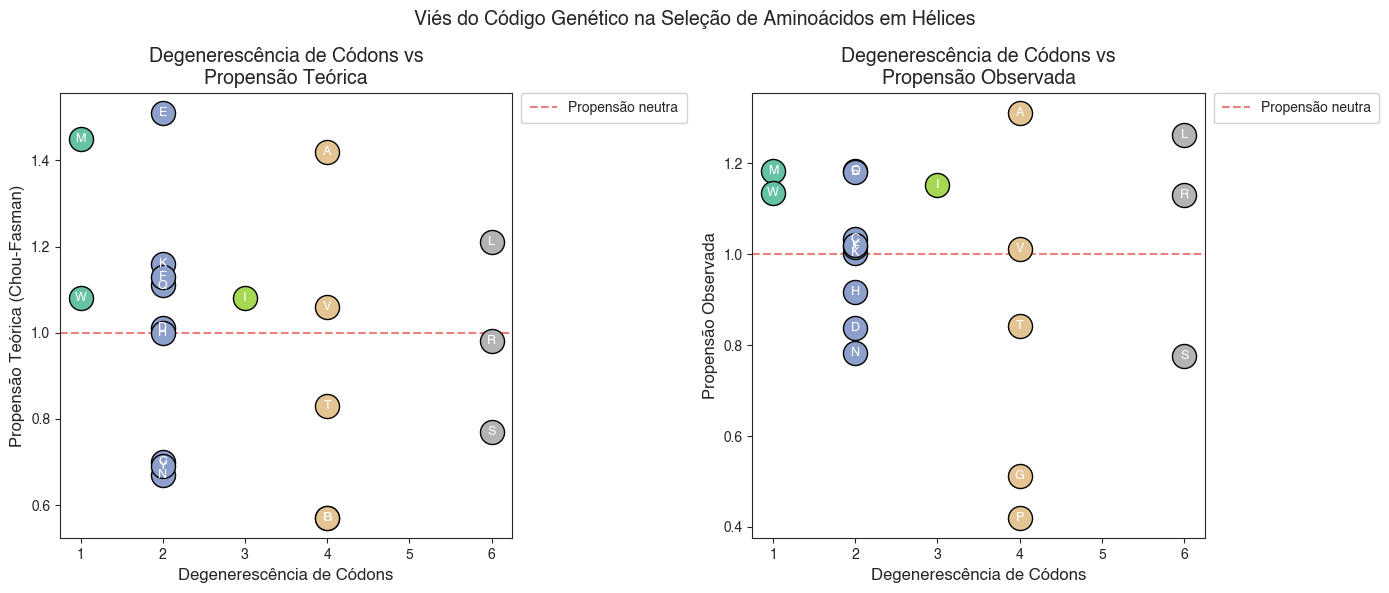

In [ ]:
# ── Estilo ────────────────────────────────────────────────────────────────────
figsize       = (14, 6)
cmap          = 'Set2'
scatter_size  = 300
annot_size    = FONT_ANNOT

# ── Plot ──────────────────────────────────────────────────────────────────────
uniq_deg  = sorted(codon_df['Codon_Degeneracy'].unique())
palette   = plt.cm.get_cmap(cmap)(np.linspace(0, 1, len(uniq_deg)))
color_map = {d: palette[i] for i, d in enumerate(uniq_deg)}

fig, axes = plt.subplots(1, 2, figsize=figsize)

for col, ylabel, title in [
    ('Propensity_Theoretical', 'Propensão Teórica (Chou-Fasman)', 'Propensão Teórica'),
    ('Propensity_Observed',    'Propensão Observada',             'Propensão Observada'),
]:
    ax = axes[0] if 'Theoretical' in col else axes[1]
    for _, row in codon_df.iterrows():
        c = color_map[row['Codon_Degeneracy']]
        ax.scatter(row['Codon_Degeneracy'], row[col], color=c, s=scatter_size, edgecolors='black', zorder=5)
        ax.text(row['Codon_Degeneracy'], row[col], row['AA'],
                ha='center', va='center', fontsize=annot_size, fontweight='bold', color='white', zorder=6)
    ax.axhline(1.0, color=COR_REF, linestyle='--', alpha=0.5, label='Propensão neutra')
    ax.set_xlabel('Degenerescência de Códons'); ax.set_ylabel(ylabel)
    ax.set_title(f'Degenerescência de Códons vs\n{title}')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

fig.suptitle('Viés do Código Genético na Seleção de Aminoácidos em Hélices',
             fontsize=FONT_TITLE, fontweight='bold')
fig.tight_layout(pad=1.5)
fig.subplots_adjust(right=0.78)
fig.savefig(ANALYSIS / 'codon_degeneracy_vs_propensity.png')
plt.show()

---
## Plot 20 — Enriquecimento vs Proteoma Humano

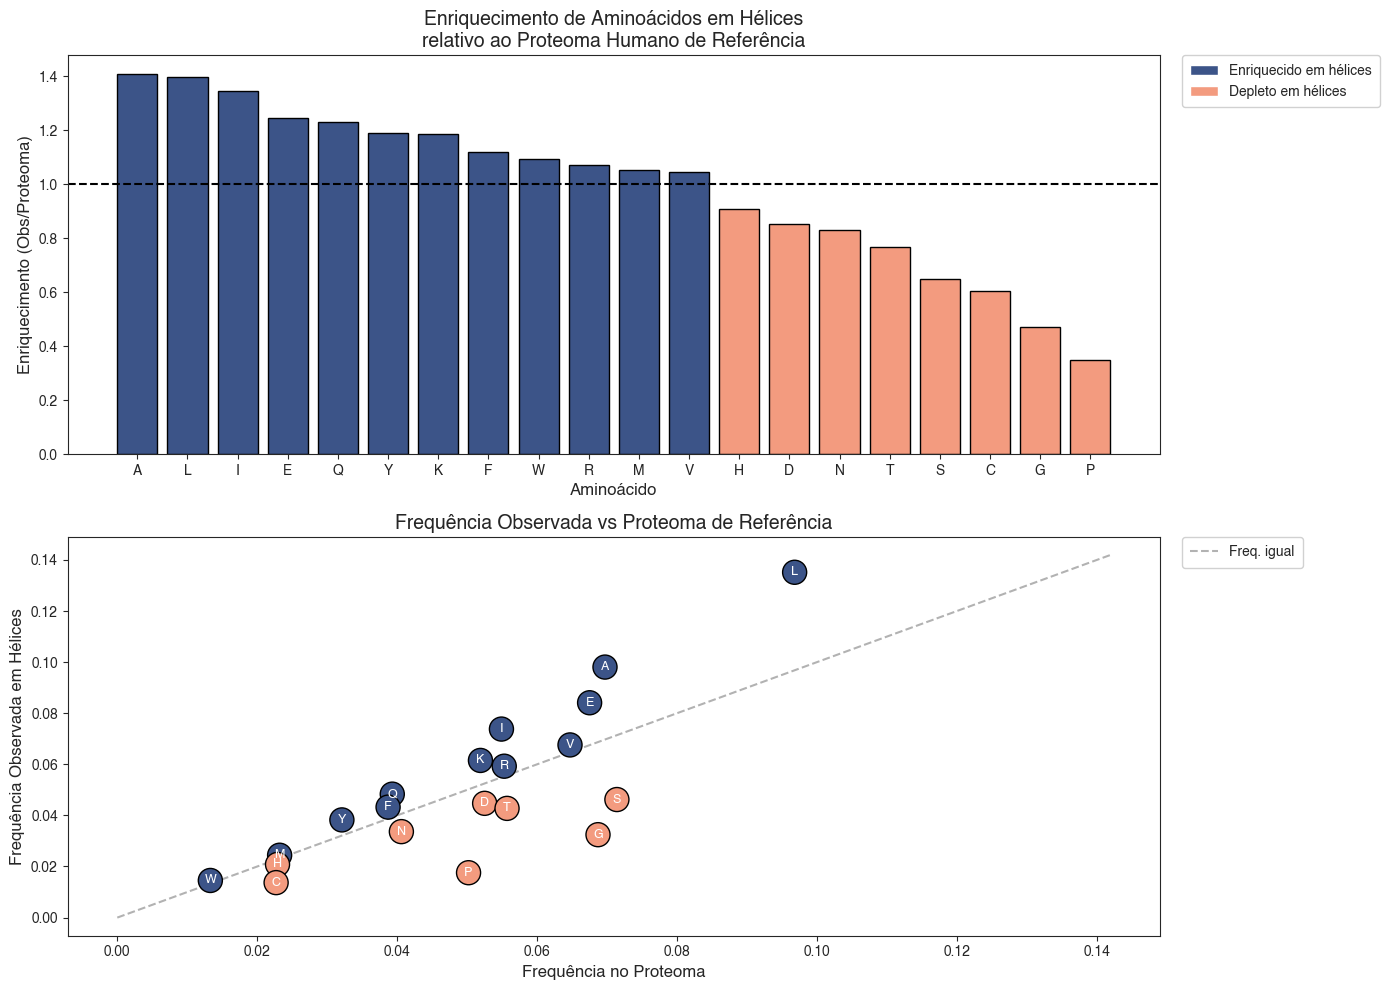

In [ ]:
# ── Estilo ────────────────────────────────────────────────────────────────────
figsize       = (14, 10)
cor_enrich    = COR_A
cor_deplete   = COR_B
bar_edge      = 'black'
scatter_size  = 300

# ── Plot ──────────────────────────────────────────────────────────────────────
df = proteome_df.sort_values('Enrichment', ascending=False)

log2_enr  = np.log2(df['Enrichment'].clip(lower=1e-10))
colors    = [cor_enrich if x >= 0 else cor_deplete for x in log2_enr]

freq_prot_log = np.log2(df['Freq_Proteome'].clip(lower=1e-10) / 100)
freq_obs_log  = np.log2(df['Freq_Observed'].clip(lower=1e-10) / 100)

fig, axes = plt.subplots(2, 1, figsize=figsize)

axes[0].bar(df['AA'], log2_enr, color=colors, edgecolor=bar_edge)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Aminoácido')
axes[0].set_ylabel('log₂ Enriquecimento (Obs/Proteoma)')
axes[0].set_title('Enriquecimento de Aminoácidos em Hélices\nrelativo ao Proteoma Humano de Referência (log₂)')
axes[0].grid(axis='y', alpha=GRID_ALPHA)
axes[0].legend(handles=[Patch(facecolor=cor_enrich, label='Enriquecido em hélices'),
                          Patch(facecolor=cor_deplete, label='Depleto em hélices')],
               bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

axes[1].scatter(freq_prot_log, freq_obs_log,
                s=scatter_size, c=colors, edgecolors='black', zorder=5)
for _, row in df.iterrows():
    axes[1].text(np.log2(row['Freq_Proteome']/100), np.log2(row['Freq_Observed']/100), row['AA'],
                 ha='center', va='center', fontsize=FONT_ANNOT, fontweight='bold', color='white', zorder=6)
mn = min(freq_prot_log.min(), freq_obs_log.min())
mx = max(freq_prot_log.max(), freq_obs_log.max())
axes[1].plot([mn, mx], [mn, mx], 'k--', alpha=0.3, label='Freq. igual')
axes[1].set_xlabel('log₂ Frequência no Proteoma')
axes[1].set_ylabel('log₂ Frequência Observada em Hélices')
axes[1].set_title('Frequência Observada vs Proteoma de Referência (escala log₂)')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
axes[1].grid(alpha=GRID_ALPHA)

fig.tight_layout(pad=1.5)
fig.subplots_adjust(right=0.78)
fig.savefig(ANALYSIS / 'proteome_comparison.png')
plt.show()